# Task 4: Customer Data Analysis

## Dataset: Supermarket Sales

### Objective

To analyze customer information and purchasing behavior using supermarket sales data.

### Purpose

The analysis focuses on customer types, gender, purchasing patterns, product preferences, sales, and ratings. Customer segmentation is performed to identify valuable customer groups and understand their purchasing behavior.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sales = pd.read_csv("SuperMarket Analysis.csv")

print("Dataset loaded successfully!")
sales.head()

Dataset loaded successfully!


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
sales.shape

(1000, 17)

In [4]:
sales.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Sales',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

In [5]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [6]:
sales.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [7]:
sales.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [8]:
sales.duplicated().sum()

np.int64(0)

## convert the date

In [9]:
sales["Date"] = pd.to_datetime(
    sales["Date"],
    errors="coerce"
)

## Analyze customer types

In [10]:
customer_type_counts = sales["Customer type"].value_counts()

customer_type_counts

Customer type
Member    565
Normal    435
Name: count, dtype: int64

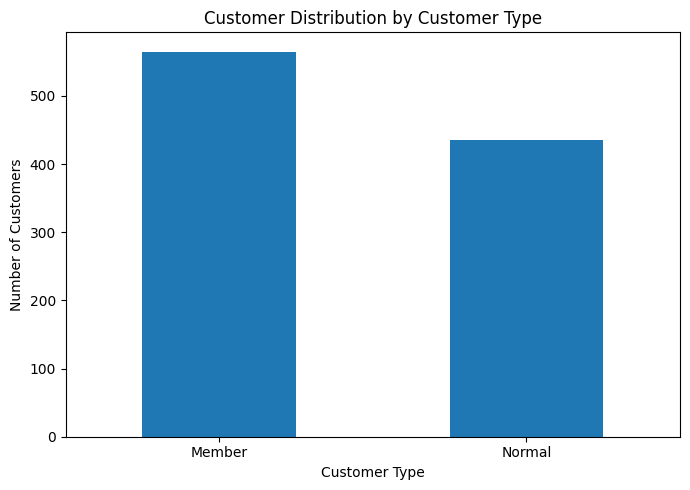

In [11]:
plt.figure(figsize=(7, 5))

customer_type_counts.plot(kind="bar")

plt.title("Customer Distribution by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [12]:
customer_type_sales = sales.groupby(
    "Customer type"
)["Sales"].sum().sort_values(ascending=False)

customer_type_sales

Customer type
Member    189694.764
Normal    133271.985
Name: Sales, dtype: float64

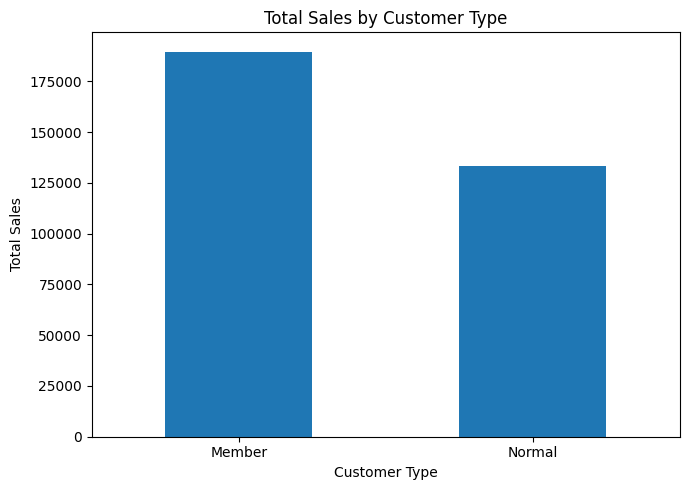

In [13]:
plt.figure(figsize=(7, 5))

customer_type_sales.plot(kind="bar")

plt.title("Total Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Analyze gender

In [14]:
gender_counts = sales["Gender"].value_counts()

gender_counts

Gender
Female    571
Male      429
Name: count, dtype: int64

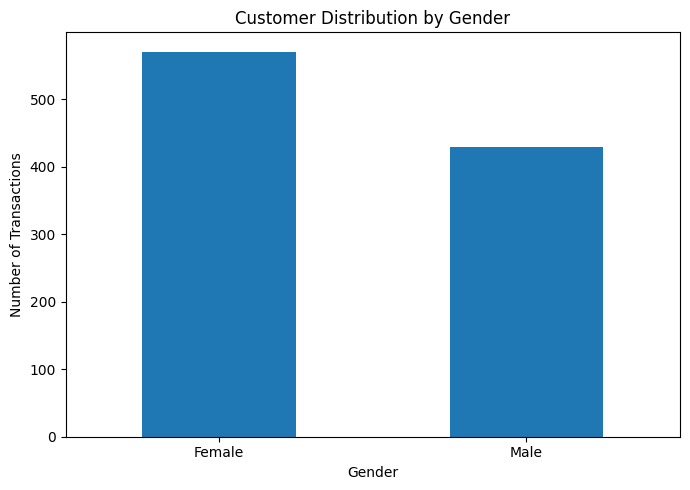

In [15]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Sales by gender

In [16]:
gender_sales = sales.groupby("Gender")["Sales"].sum()

gender_sales

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64

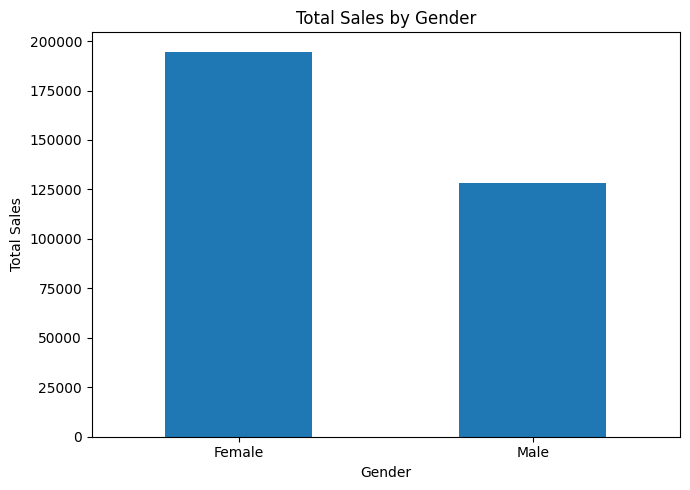

In [17]:
plt.figure(figsize=(7, 5))

gender_sales.plot(kind="bar")

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Customer purchasing behavior

In [18]:
average_customer_type_sales = sales.groupby(
    "Customer type"
)["Sales"].mean().sort_values(ascending=False)

average_customer_type_sales

Customer type
Member    335.742945
Normal    306.372379
Name: Sales, dtype: float64

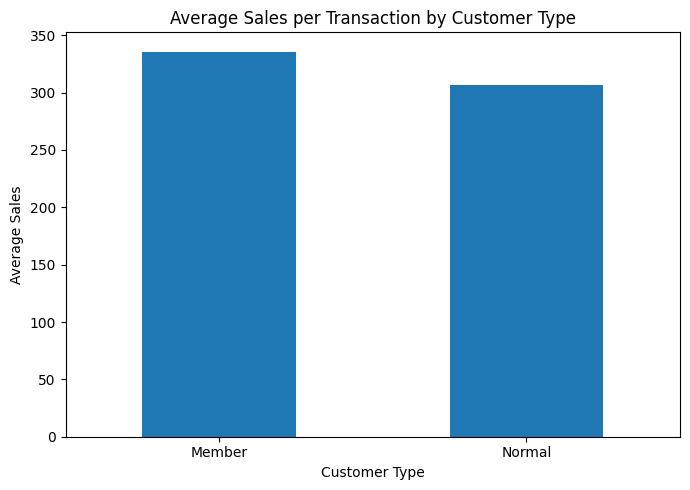

In [19]:
plt.figure(figsize=(7, 5))

average_customer_type_sales.plot(kind="bar")

plt.title("Average Sales per Transaction by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Product preferences by customer type

In [20]:
customer_product = pd.crosstab(
    sales["Customer type"],
    sales["Product line"]
)

customer_product

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Customer type,,,,,,
Member,90,96,104,86,92,97
Normal,80,82,70,66,68,69


customer_product.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Product Preferences by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Find the most valuable customer groups

In [22]:
group_sales = sales.groupby(
    ["Customer type", "Gender"]
)["Sales"].agg(
    ["count", "sum", "mean"]
).sort_values(
    "sum",
    ascending=False
)

group_sales

,,count,sum,mean
Customer type,Gender,,,
Member,Female,356,125206.1370,351.702632
Normal,Female,215,69465.7005,323.096281
Member,Male,209,64488.6270,308.558024
Normal,Male,220,63806.2845,290.028566


## Branch + customer type analysis

In [23]:
branch_customer_sales = sales.groupby(
    ["Branch", "Customer type"]
)["Sales"].sum().unstack()

branch_customer_sales

Customer type,Member,Normal
Branch,,
Alex,62895.777,43304.5935
Cairo,59824.170,46373.5020
Giza,66974.817,43593.8895


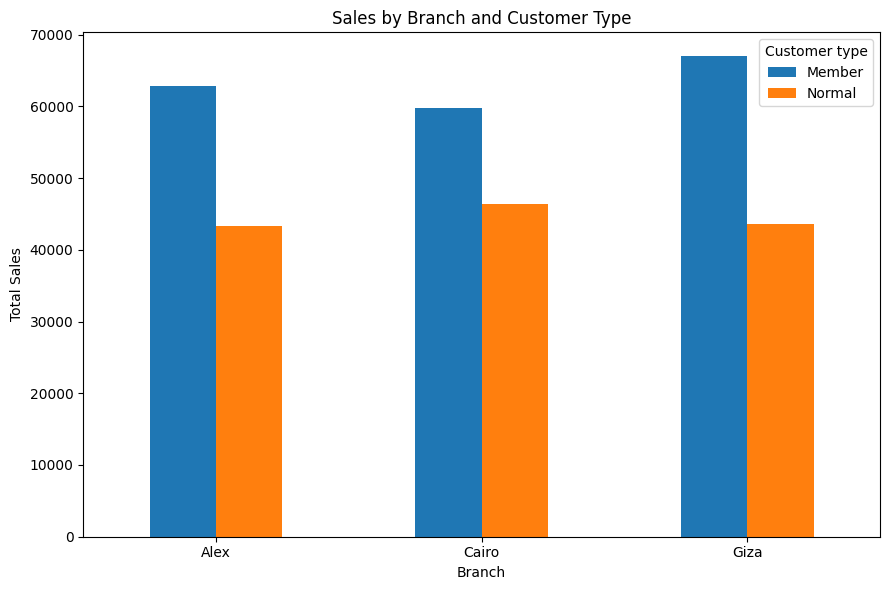

In [24]:
branch_customer_sales.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Sales by Branch and Customer Type")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Customer rating analysis

In [25]:
customer_rating = sales.groupby(
    "Customer type"
)["Rating"].mean()

customer_rating

Customer type
Member    6.917168
Normal    7.044828
Name: Rating, dtype: float64

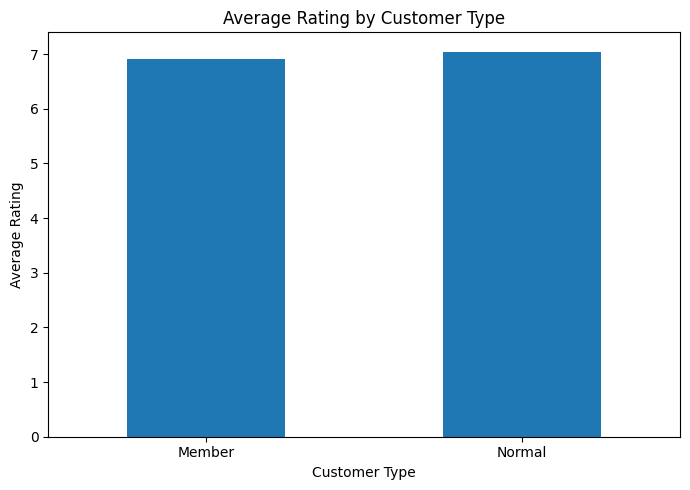

In [26]:
plt.figure(figsize=(7, 5))

customer_rating.plot(kind="bar")

plt.title("Average Rating by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Create customer segments

In [28]:
sales["Sales Level"] = pd.cut(
    sales["Sales"],
    bins=[0, 100, 250, float("inf")],
    labels=["Low", "Medium", "High"]
)

In [29]:
sales["Quantity Level"] = pd.cut(
    sales["Quantity"],
    bins=[0, 5, 8, float("inf")],
    labels=["Low", "Medium", "High"]
)

In [30]:
sales[
    ["Sales", "Quantity", "Sales Level", "Quantity Level"]
].head()

,Sales,Quantity,Sales Level,Quantity Level
0,548.9715,7,High,Medium
1,80.2200,5,Low,Low
2,340.5255,7,High,Medium
3,489.0480,8,High,Medium
4,634.3785,7,High,Medium


## Analyze the segments

In [31]:
segment_analysis = sales.groupby(
    ["Sales Level", "Quantity Level"],
    observed=True
)["Sales"].agg(
    ["count", "sum", "mean"]
).sort_values(
    "sum",
    ascending=False
)

segment_analysis

count          sum        mean
Sales Level Quantity Level                                
High        High              172  111478.6050  648.131424
            Medium            213  107148.3630  503.043958
            Low               125   42989.1840  343.913472
Medium      Low               183   30737.6160  167.965115
Low         Low               196   12091.3800   61.690714
Medium      Medium             60   10266.9315  171.115525
            High               39    7233.7965  185.481962
Low         Medium             12    1020.8730   85.072750

## Most valuable segment

In [32]:
most_valuable_segment = segment_analysis.iloc[0]

most_valuable_segment

count       172.000000
sum      111478.605000
mean        648.131424
Name: (High, High), dtype: float64

In [33]:
print(
    "Most valuable purchasing segment:",
    segment_analysis.index[0]
)

Most valuable purchasing segment: ('High', 'High')


## Create the visual report

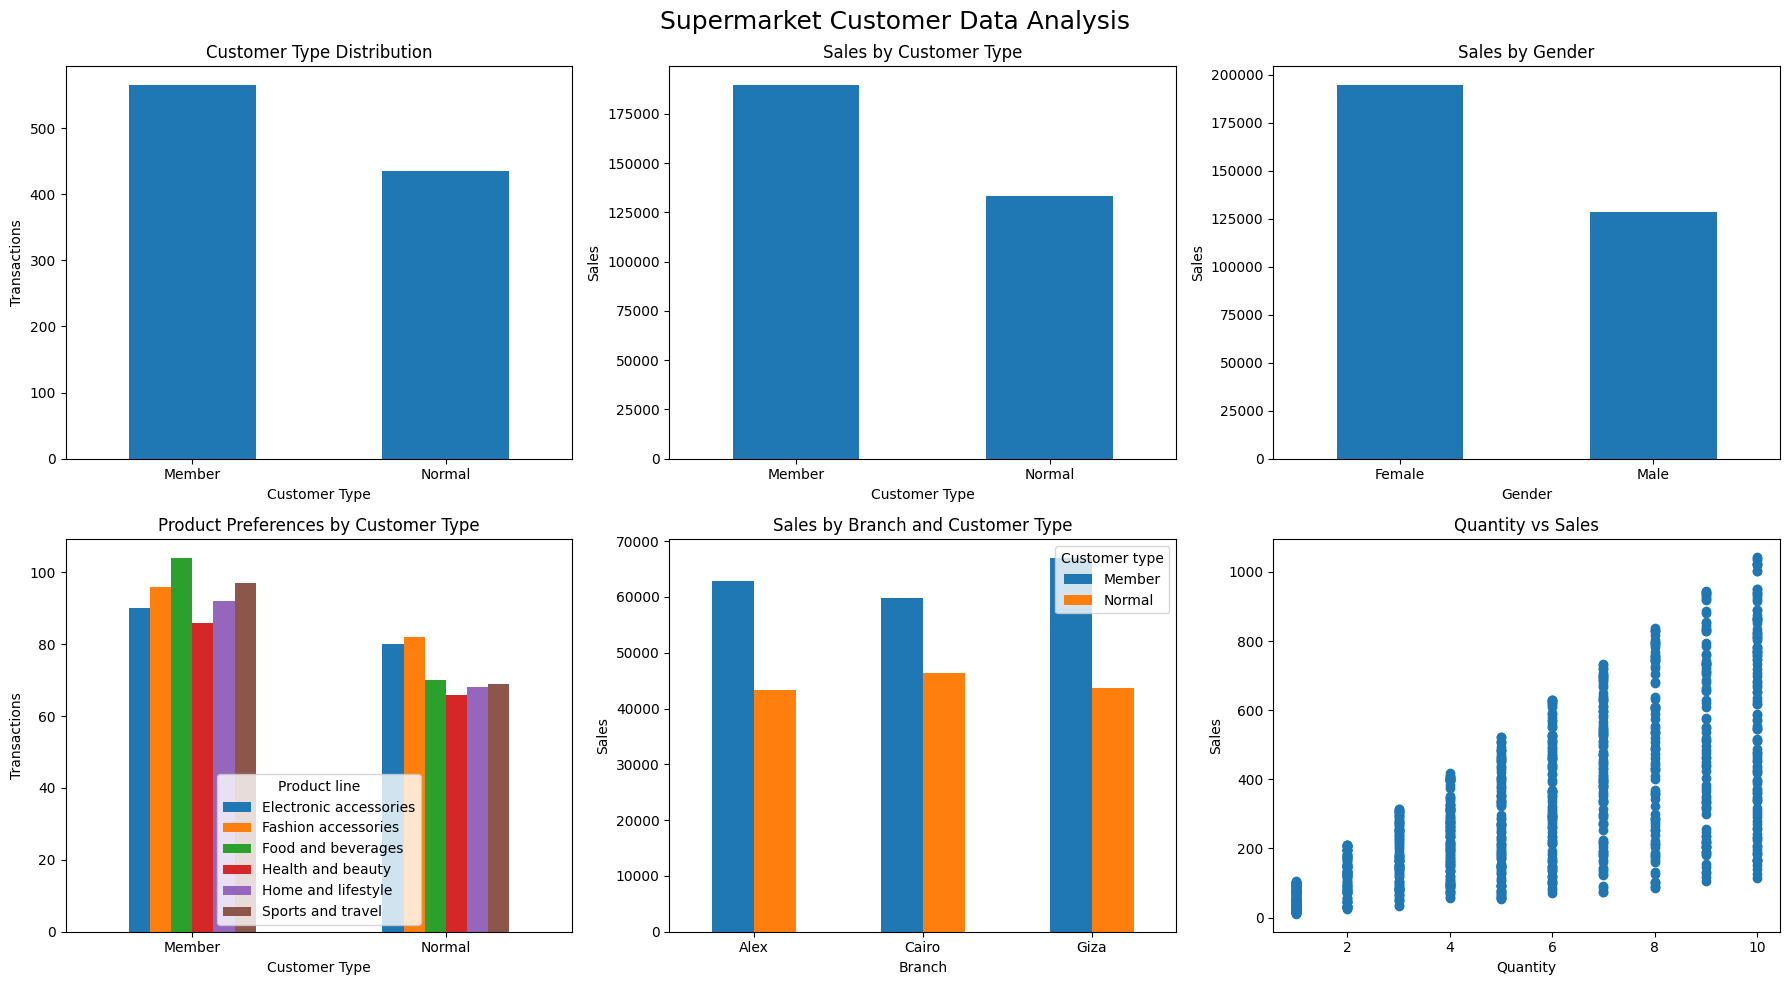

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Customer Type
customer_type_counts.plot(
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Customer Type Distribution")
axes[0, 0].set_xlabel("Customer Type")
axes[0, 0].set_ylabel("Transactions")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2. Sales by Customer Type
customer_type_sales.plot(
    kind="bar",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Sales by Customer Type")
axes[0, 1].set_xlabel("Customer Type")
axes[0, 1].set_ylabel("Sales")
axes[0, 1].tick_params(axis="x", rotation=0)

# 3. Gender Sales
gender_sales.plot(
    kind="bar",
    ax=axes[0, 2]
)
axes[0, 2].set_title("Sales by Gender")
axes[0, 2].set_xlabel("Gender")
axes[0, 2].set_ylabel("Sales")
axes[0, 2].tick_params(axis="x", rotation=0)

# 4. Product Preferences
customer_product.plot(
    kind="bar",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Product Preferences by Customer Type")
axes[1, 0].set_xlabel("Customer Type")
axes[1, 0].set_ylabel("Transactions")
axes[1, 0].tick_params(axis="x", rotation=0)

# 5. Branch + Customer Type
branch_customer_sales.plot(
    kind="bar",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Sales by Branch and Customer Type")
axes[1, 1].set_xlabel("Branch")
axes[1, 1].set_ylabel("Sales")
axes[1, 1].tick_params(axis="x", rotation=0)

# 6. Quantity vs Sales
axes[1, 2].scatter(
    sales["Quantity"],
    sales["Sales"]
)
axes[1, 2].set_title("Quantity vs Sales")
axes[1, 2].set_xlabel("Quantity")
axes[1, 2].set_ylabel("Sales")

plt.suptitle(
    "Supermarket Customer Data Analysis",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    "customer_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
sales.to_csv(
    "customer_analysis.csv",
    index=False
)

print("Customer analysis dataset saved successfully!")

Customer analysis dataset saved successfully!


# Marketing Strategies

## 1. Member Customers

Members can be encouraged to make repeat purchases through loyalty rewards, personalized offers, and member-exclusive promotions.

## 2. Normal Customers

Normal customers can be encouraged to become members through introductory discounts and loyalty program benefits.

## 3. High-Value Transactions

Customers making high-value purchases can be targeted with product bundles, premium offers, and personalized recommendations.

## 4. Product-Based Promotions

Frequently purchased product lines can be promoted through discounts and bundled offers to encourage additional purchases.

## 5. Branch-Specific Strategies

Differences in customer purchasing behavior between branches can be used to design location-specific promotions and improve customer engagement.

# Conclusion

The customer data analysis provided insights into purchasing behavior across customer types, genders, branches, and product lines. The analysis identified differences in transaction frequency, sales contribution, average spending, and product preferences.

Customer segmentation based on sales value and quantity helped identify different purchasing groups. These insights can be used to develop targeted marketing strategies, improve customer engagement, encourage repeat purchases, and focus promotional activities on valuable customer groups.